# EDA C-MAPSS FD001

Objetivo: entender la estructura del subconjunto FD001, construir la variable objetivo RUL para entrenamiento y detectar decisiones importantes para el modelado posterior.

Preguntas guia:
- Cuantos motores y ciclos hay en train/test?
- Hay valores faltantes, duplicados o columnas constantes?
- Como se distribuye la vida util restante en train?
- Que sensores parecen asociarse con degradacion?
- Como se organiza el target real de test: una etiqueta por motor en el ultimo ciclo observado?


## 1. Setup

El notebook usa funciones reutilizables de `src/` para mantener la carga y los chequeos consistentes con los futuros notebooks de baseline y modelos.


In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

PROJECT_ROOT = Path.cwd().resolve()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.data import (
    FEATURE_COLUMNS,
    SENSOR_COLUMNS,
    SETTING_COLUMNS,
    add_train_rul,
    last_cycle_rows,
    load_cmapss_subset,
    unit_last_cycles,
)
from src.eda import (
    constant_columns,
    correlation_with_target,
    cycle_summary,
    dataset_overview,
    low_variance_columns,
    missing_summary,
    numeric_summary,
    train_test_distribution_shift,
)

pd.set_option("display.max_columns", 80)
pd.set_option("display.float_format", lambda value: f"{value:,.4f}")

FIGURES_DIR = PROJECT_ROOT / "outputs" / "figures"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

RANDOM_STATE = 42


## 2. Carga de datos

FD001 tiene una condicion operativa y un modo de falla, por eso es el mejor punto de partida.


In [2]:
data = load_cmapss_subset("FD001", data_dir=PROJECT_ROOT / "CMAPSSData")
train_raw = data.train
test_raw = data.test
rul = data.rul

train = add_train_rul(train_raw)
test_last = last_cycle_rows(test_raw).merge(rul, on="unit", how="left")

overview = dataset_overview(train_raw, test_raw, rul)
overview


,dataset,rows,columns,units,missing_values,duplicated_rows
0,train,20631,26,100,0,0
1,test,13096,26,100,0,0
2,rul,100,2,100,0,0


## 3. Estructura por motor

Cada `unit` representa un motor. En train cada motor llega hasta falla. En test, cada trayectoria esta truncada antes de la falla; por eso `RUL_FD001.txt` contiene una sola etiqueta por motor, correspondiente al ultimo ciclo observado.


In [3]:
train_cycles = unit_last_cycles(train).assign(split="train")
test_cycles = unit_last_cycles(test_raw).assign(split="test")
cycles = pd.concat([train_cycles, test_cycles], ignore_index=True)

summary_cycles = cycles.groupby("split")["last_cycle"].describe()
summary_cycles


,count,mean,std,min,25%,50%,75%,max
split,,,,,,,,
test,100.0000,130.9600,53.5935,31.0000,88.7500,133.5000,164.2500,303.0000
train,100.0000,206.3100,46.3427,128.0000,177.0000,199.0000,229.2500,362.0000


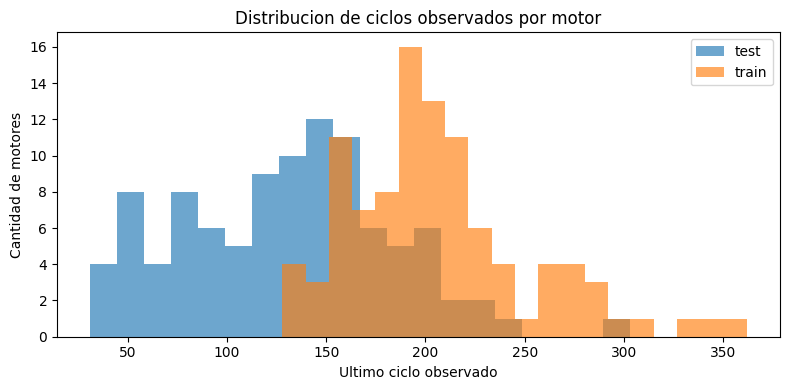

In [4]:
fig, ax = plt.subplots(figsize=(8, 4))
for split, group in cycles.groupby("split"):
    ax.hist(group["last_cycle"], bins=20, alpha=0.65, label=split)
ax.set_title("Distribucion de ciclos observados por motor")
ax.set_xlabel("Ultimo ciclo observado")
ax.set_ylabel("Cantidad de motores")
ax.legend()
fig.tight_layout()
fig.savefig(FIGURES_DIR / "fd001_cycles_by_unit.png", dpi=150)
plt.show()


## 4. Variable objetivo: RUL

En train se calcula por fila como `max_cycle_del_motor - cycle`. En test no se calcula RUL por fila para el flujo principal: el archivo `RUL_FD001.txt` da el RUL real del ultimo ciclo observado de cada motor.


In [5]:
rul_summary = pd.DataFrame({
    "train_row_rul": train["RUL"].describe(),
    "test_last_cycle_rul": rul["final_rul"].describe(),
})
rul_summary


,train_row_rul,test_last_cycle_rul
count,"20,631.0000",100.0000
mean,107.8079,75.5200
std,68.8810,41.7650
min,0.0000,7.0000
25%,51.0000,32.7500
50%,103.0000,86.0000
75%,155.0000,112.2500
max,361.0000,145.0000


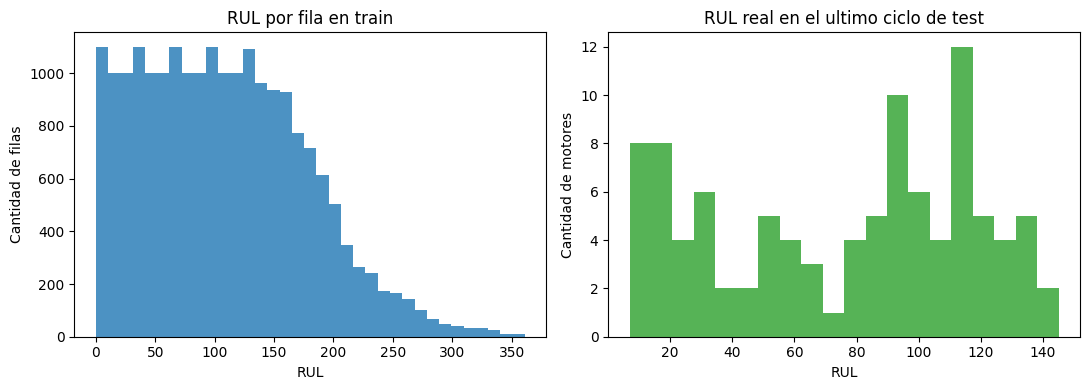

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].hist(train["RUL"], bins=35, color="tab:blue", alpha=0.8)
axes[0].set_title("RUL por fila en train")
axes[0].set_xlabel("RUL")
axes[0].set_ylabel("Cantidad de filas")

axes[1].hist(rul["final_rul"], bins=20, color="tab:green", alpha=0.8)
axes[1].set_title("RUL real en el ultimo ciclo de test")
axes[1].set_xlabel("RUL")
axes[1].set_ylabel("Cantidad de motores")

fig.tight_layout()
fig.savefig(FIGURES_DIR / "fd001_rul_distributions.png", dpi=150)
plt.show()


## 5. Calidad de datos

Chequeos basicos para detectar problemas antes de modelar.


In [8]:
quality = {
    "train_missing_values": int(train_raw.isna().sum().sum()),
    "test_missing_values": int(test_raw.isna().sum().sum()),
    "train_duplicated_rows": int(train_raw.duplicated().sum()),
    "test_duplicated_rows": int(test_raw.duplicated().sum()),
}
quality


{'train_missing_values': 0,
 'test_missing_values': 0,
 'train_duplicated_rows': 0,
 'test_duplicated_rows': 0}

In [9]:
display(missing_summary(train_raw))
display(missing_summary(test_raw))


,missing_count,missing_pct


,missing_count,missing_pct


In [10]:
constant_train = constant_columns(train_raw)
low_variance_train = low_variance_columns(train_raw)

print("Columnas constantes en train:", constant_train)
display(low_variance_train)


Columnas constantes en train: ['setting_3', 'sensor_1', 'sensor_5', 'sensor_10', 'sensor_16', 'sensor_18', 'sensor_19']


,column,variance
0,setting_3,0.0000
1,sensor_1,0.0000
2,sensor_19,0.0000
3,sensor_18,0.0000
4,sensor_10,0.0000
5,sensor_16,0.0000
6,sensor_5,0.0000


## 6. Resumen de settings y sensores

FD001 tiene una sola condicion operativa, por lo que algunas variables son constantes o casi constantes. Esas columnas suelen aportar poco al modelo.


In [11]:
feature_summary = numeric_summary(train_raw, FEATURE_COLUMNS)
feature_summary.sort_values("std").head(12)


,mean,std,min,max,p01,p25,p50,p75,p99,n_unique
setting_3,100.0000,0.0000,100.0000,100.0000,100.0000,100.0000,100.0000,100.0000,100.0000,1
sensor_1,518.6700,0.0000,518.6700,518.6700,518.6700,518.6700,518.6700,518.6700,518.6700,1
sensor_19,100.0000,0.0000,100.0000,100.0000,100.0000,100.0000,100.0000,100.0000,100.0000,1
sensor_18,"2,388.0000",0.0000,"2,388.0000","2,388.0000","2,388.0000","2,388.0000","2,388.0000","2,388.0000","2,388.0000",1
sensor_10,1.3000,0.0000,1.3000,1.3000,1.3000,1.3000,1.3000,1.3000,1.3000,1
sensor_16,0.0300,0.0000,0.0300,0.0300,0.0300,0.0300,0.0300,0.0300,0.0300,1
sensor_5,14.6200,0.0000,14.6200,14.6200,14.6200,14.6200,14.6200,14.6200,14.6200,1
setting_2,0.0000,0.0003,-0.0006,0.0006,-0.0005,-0.0002,0.0000,0.0003,0.0005,13
sensor_6,21.6098,0.0014,21.6000,21.6100,21.6000,21.6100,21.6100,21.6100,21.6100,2
setting_1,-0.0000,0.0022,-0.0087,0.0087,-0.0051,-0.0015,0.0000,0.0015,0.0050,158


In [12]:
feature_summary.sort_values("std", ascending=False).head(12)


,mean,std,min,max,p01,p25,p50,p75,p99,n_unique
sensor_9,"9,065.2429",22.0829,"9,021.7300","9,244.5900","9,036.3500","9,053.1000","9,060.6600","9,069.4200","9,155.2390",6403
sensor_14,"8,143.7527",19.0762,"8,099.9400","8,293.7200","8,115.4160","8,133.2450","8,140.5400","8,148.3100","8,220.0200",6078
sensor_4,"1,408.9338",9.0006,"1,382.2500","1,441.4900","1,391.8830","1,402.3600","1,408.0400","1,414.5550","1,431.5170",4051
sensor_3,"1,590.5231",6.1311,"1,571.0400","1,616.9100","1,577.6130","1,586.2600","1,590.1000","1,594.3800","1,605.8710",3012
sensor_17,393.2107,1.5488,388.0000,400.0000,390.0000,392.0000,393.0000,394.0000,397.0000,13
sensor_7,553.3677,0.8851,549.8500,556.0600,551.1600,552.8100,553.4400,554.0100,555.0700,513
sensor_12,521.4135,0.7376,518.6900,523.3800,519.5500,520.9600,521.4800,521.9500,522.8000,427
sensor_2,642.6809,0.5001,641.2100,644.5300,641.6500,642.3250,642.6400,643.0000,643.9300,310
sensor_11,47.5412,0.2671,46.8500,48.5300,47.0500,47.3500,47.5100,47.7000,48.2100,159
sensor_20,38.8163,0.1807,38.1400,39.4300,38.3700,38.7000,38.8300,38.9500,39.1800,120


## 7. Evolucion temporal de sensores

Se observan motores representativos para ver tendencias de degradacion. Conviene mirar sensores con alta correlacion absoluta con RUL y algunos sensores constantes como control.


In [13]:
corr = correlation_with_target(train, target="RUL", columns=FEATURE_COLUMNS)
corr.head(12)


,correlation,abs_correlation
sensor_11,-0.6962,0.6962
sensor_4,-0.6789,0.6789
sensor_12,0.6720,0.6720
sensor_7,0.6572,0.6572
sensor_15,-0.6427,0.6427
sensor_21,0.6357,0.6357
sensor_20,0.6294,0.6294
sensor_2,-0.6065,0.6065
sensor_17,-0.6062,0.6062
sensor_3,-0.5845,0.5845


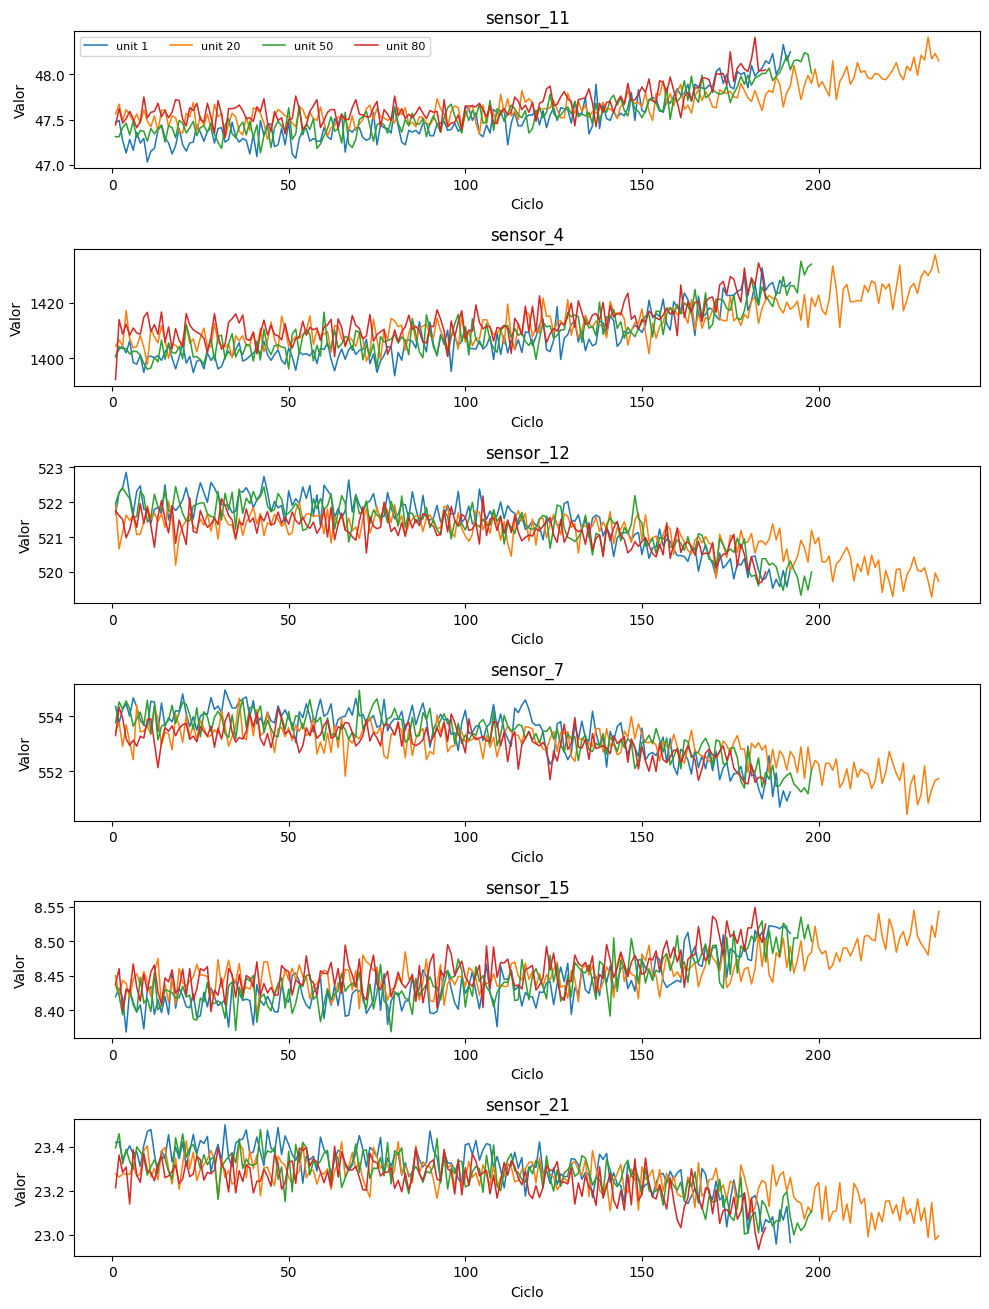

In [14]:
top_sensors = [column for column in corr.index if column.startswith("sensor_")][:6]
example_units = [1, 20, 50, 80]

fig, axes = plt.subplots(len(top_sensors), 1, figsize=(10, 2.2 * len(top_sensors)), sharex=False)
for ax, sensor in zip(axes, top_sensors):
    for unit in example_units:
        unit_df = train.loc[train["unit"] == unit]
        ax.plot(unit_df["cycle"], unit_df[sensor], linewidth=1.1, label=f"unit {unit}")
    ax.set_title(sensor)
    ax.set_xlabel("Ciclo")
    ax.set_ylabel("Valor")
axes[0].legend(ncol=4, fontsize=8)
fig.tight_layout()
fig.savefig(FIGURES_DIR / "fd001_top_sensor_trends.png", dpi=150)
plt.show()


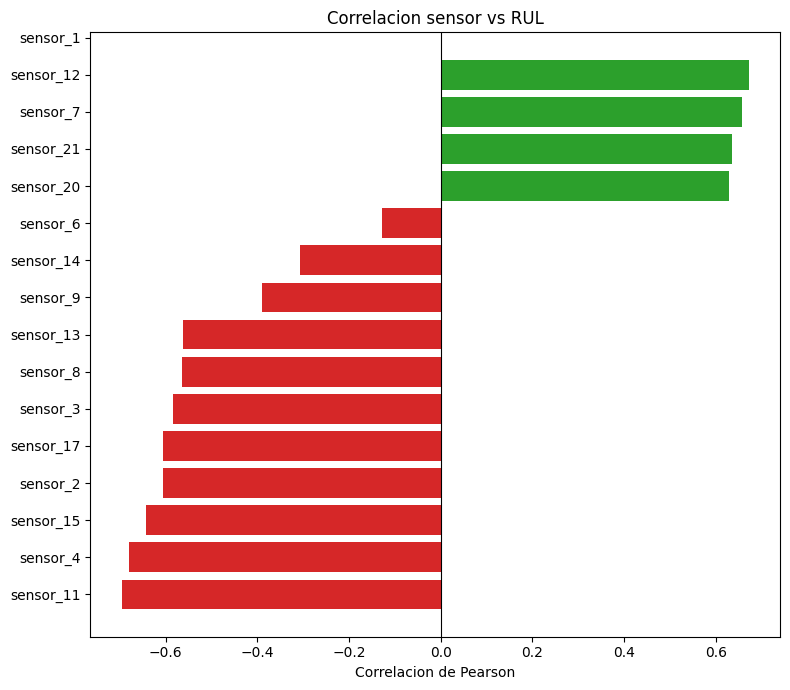

In [15]:
fig, ax = plt.subplots(figsize=(8, 7))
ordered_corr = corr.loc[[c for c in corr.index if c in SENSOR_COLUMNS]].sort_values("correlation")
ax.barh(ordered_corr.index, ordered_corr["correlation"], color=np.where(ordered_corr["correlation"] >= 0, "tab:green", "tab:red"))
ax.axvline(0, color="black", linewidth=0.8)
ax.set_title("Correlacion sensor vs RUL")
ax.set_xlabel("Correlacion de Pearson")
fig.tight_layout()
fig.savefig(FIGURES_DIR / "fd001_sensor_rul_correlations.png", dpi=150)
plt.show()


## 8. Comparacion train/test

Se compara la distribucion de variables observadas entre train y test, teniendo presente que test esta truncado antes de la falla. Para el problema final, cada prediccion debe corresponder al ultimo ciclo observado de cada motor de test.


In [16]:
shift = train_test_distribution_shift(train_raw, test_raw, FEATURE_COLUMNS)
shift.head(12)


,column,train_mean,test_mean,mean_diff,standardized_mean_diff,train_std,test_std,train_min,test_min,train_max,test_max
12,sensor_10,1.3000,1.3000,0.0000,1.0000,0.0000,0.0000,1.3000,1.3000,1.3000,1.3000
13,sensor_11,47.5412,47.4162,-0.1250,-0.5009,0.2671,0.1959,46.8500,46.8000,48.5300,48.2600
6,sensor_4,"1,408.9338","1,404.7354",-4.1984,-0.4979,9.0006,6.6883,"1,382.2500","1,384.3900","1,441.4900","1,433.3600"
14,sensor_12,521.4135,521.7477,0.3343,0.4820,0.7376,0.5596,518.6900,519.3800,523.3800,523.7600
9,sensor_7,553.3677,553.7575,0.3898,0.4674,0.8851,0.6813,549.8500,550.8800,556.0600,555.8400
17,sensor_15,8.4421,8.4258,-0.0163,-0.4610,0.0375,0.0290,8.3249,8.3328,8.5848,8.5414
23,sensor_21,23.2897,23.3357,0.0460,0.4510,0.1083,0.0841,22.8942,22.9354,23.6184,23.6419
22,sensor_20,38.8163,38.8925,0.0762,0.4464,0.1807,0.1417,38.1400,38.3100,39.4300,39.4100
19,sensor_17,393.2107,392.5716,-0.6390,-0.4353,1.5488,1.2336,388.0000,389.0000,400.0000,397.0000
4,sensor_2,642.6809,642.4751,-0.2058,-0.4336,0.5001,0.4009,641.2100,641.1300,644.5300,644.3000


In [17]:
test_prediction_frame = test_last[["unit", "cycle", "final_rul"] + FEATURE_COLUMNS]
print(f"Filas para evaluacion de test: {len(test_prediction_frame)}")
display(test_prediction_frame.head())
display(test_prediction_frame[["cycle", "final_rul"]].describe())


Filas para evaluacion de test: 100


,unit,cycle,final_rul,setting_1,setting_2,setting_3,sensor_1,sensor_2,sensor_3,sensor_4,sensor_5,sensor_6,sensor_7,sensor_8,sensor_9,sensor_10,sensor_11,sensor_12,sensor_13,sensor_14,sensor_15,sensor_16,sensor_17,sensor_18,sensor_19,sensor_20,sensor_21
0,1,31,112,-0.0006,0.0004,100.0000,518.6700,642.5800,"1,581.2200","1,398.9100",14.6200,21.6100,554.4200,"2,388.0800","9,056.4000",1.3000,47.2300,521.7900,"2,388.0600","8,130.1100",8.4024,0.0300,393,2388,100.0000,38.8100,23.3552
1,2,49,98,0.0018,-0.0001,100.0000,518.6700,642.5500,"1,586.5900","1,410.8300",14.6200,21.6100,553.5200,"2,388.1000","9,044.7700",1.3000,47.6700,521.7400,"2,388.0900","8,126.9000",8.4505,0.0300,391,2388,100.0000,38.8100,23.2618
2,3,126,69,-0.0016,0.0004,100.0000,518.6700,642.8800,"1,589.7500","1,418.8900",14.6200,21.6100,552.5900,"2,388.1600","9,049.2600",1.3000,47.8800,520.8300,"2,388.1400","8,131.4600",8.4119,0.0300,395,2388,100.0000,38.9300,23.2740
3,4,106,82,0.0012,0.0004,100.0000,518.6700,642.7800,"1,594.5300","1,406.8800",14.6200,21.6100,552.6400,"2,388.1300","9,051.3000",1.3000,47.6500,521.8800,"2,388.1100","8,133.6400",8.4634,0.0300,395,2388,100.0000,38.5800,23.2581
4,5,98,91,-0.0013,-0.0004,100.0000,518.6700,642.2700,"1,589.9400","1,419.3600",14.6200,21.6100,553.2900,"2,388.1000","9,053.9900",1.3000,47.4600,521.0000,"2,388.1500","8,125.7400",8.4362,0.0300,394,2388,100.0000,38.7500,23.4117


,cycle,final_rul
count,100.0000,100.0000
mean,130.9600,75.5200
std,53.5935,41.7650
min,31.0000,7.0000
25%,88.7500,32.7500
50%,133.5000,86.0000
75%,164.2500,112.2500
max,303.0000,145.0000


C:\Users\lauta\AppData\Local\Temp\ipykernel_9488\3024761830.py:4: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot([train_raw[column], test_raw[column]], labels=["train", "test"], showfliers=False)
C:\Users\lauta\AppData\Local\Temp\ipykernel_9488\3024761830.py:4: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot([train_raw[column], test_raw[column]], labels=["train", "test"], showfliers=False)
C:\Users\lauta\AppData\Local\Temp\ipykernel_9488\3024761830.py:4: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot([train_raw[column], test_raw[column]], labels=["train", "test"], showfliers=False)
C:\User

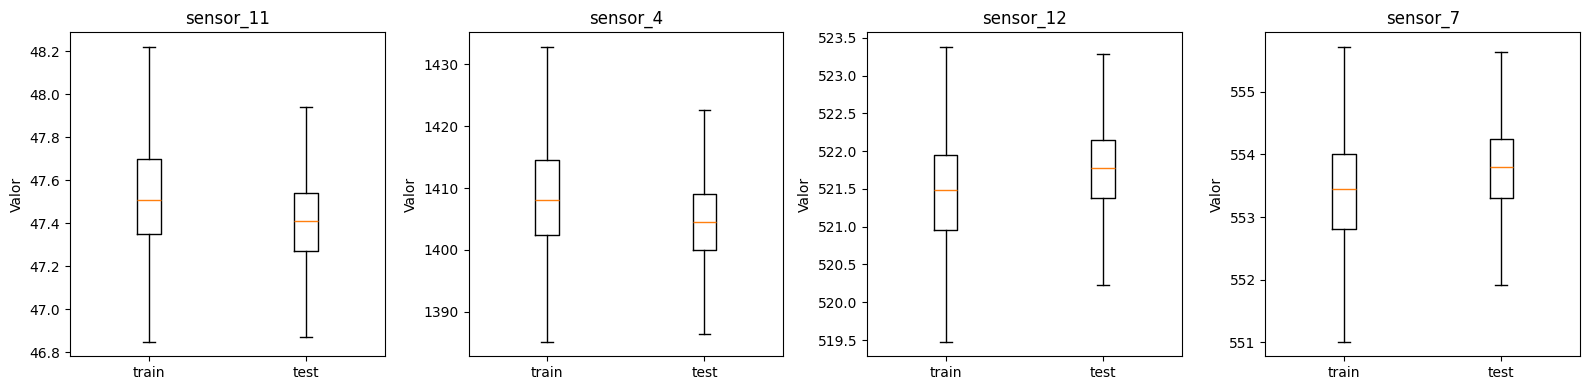

In [18]:
selected_for_boxplot = top_sensors[:4]
fig, axes = plt.subplots(1, len(selected_for_boxplot), figsize=(4 * len(selected_for_boxplot), 4))
for ax, column in zip(axes, selected_for_boxplot):
    ax.boxplot([train_raw[column], test_raw[column]], labels=["train", "test"], showfliers=False)
    ax.set_title(column)
    ax.set_ylabel("Valor")
fig.tight_layout()
fig.savefig(FIGURES_DIR / "fd001_train_test_sensor_boxplots.png", dpi=150)
plt.show()
